# 🎵 Wizualizacja rynku koncertów muzycznych w Polsce

## Big Data

**Autor:** Cyprian

Celem analizy jest eksploracja danych dotyczących koncertów organizowanych w Polsce z wykorzystaniem biblioteki Plotly. Notebook przedstawia analizę statystyczną oraz zestaw interaktywnych wizualizacji.

In [2]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Część 1 — Wczytanie i wstępna eksploracja danych

In [3]:
df = pd.read_csv(
    "koncerty_polska.csv",
    parse_dates=["data"]
)

print("===== SHAPE =====")
print(df.shape)

print("\n===== HEAD =====")
print(df.head())

print("\n===== DTYPES =====")
print(df.dtypes)

print("\n===== UNIKALNE MIASTA =====")
print(df["miasto"].nunique())

print("\n===== UNIKALNE GATUNKI =====")
print(df["gatunek"].nunique())

===== SHAPE =====
(1200, 11)

===== HEAD =====
   event_id       data    miasto  latitude  longitude    gatunek typ_obiektu  \
0     50001 2024-04-12    Poznań   52.4064    16.9252    hip-hop        klub   
1     50002 2025-03-11    Gdańsk   54.3520    18.6466       folk       arena   
2     50003 2024-09-27  Warszawa   52.2297    21.0122  classical        klub   
3     50004 2024-04-16  Katowice   50.2649    19.0238      metal        klub   
4     50005 2024-03-12    Poznań   52.4064    16.9252      metal        klub   

   pojemnosc  bilety_sprzedane  cena_biletu_pln  przychod_pln  
0        410               316            170.0         53720  
1       5799              2512            130.0        326560  
2        634               414            100.0         41400  
3        979               735            100.0         73500  
4       1430               808             80.0         64640  

===== DTYPES =====
event_id                     int64
data                datetime64[us

## Wnioski po wczytaniu danych

- Dane zostały poprawnie wczytane.
- Zbiór zawiera informacje o koncertach organizowanych w 10 polskich miastach.
- Występuje 10 różnych gatunków muzycznych.
- Kolumna `data` została poprawnie odczytana jako typ daty, co umożliwia analizę szeregu czasowego.

# Część 2 — Łączny przychód według miasta

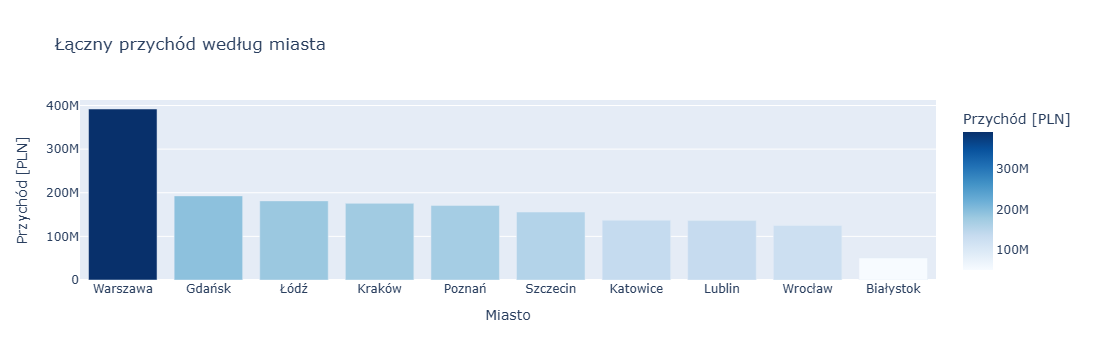

In [4]:
przychody = (
    df.groupby("miasto")["przychod_pln"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig = px.bar(
    przychody,
    x="miasto",
    y="przychod_pln",
    title="Łączny przychód według miasta",
    labels={
        "miasto": "Miasto",
        "przychod_pln": "Przychód [PLN]"
    },
    color="przychod_pln",
    color_continuous_scale="Blues"
)

fig.show()

### Komentarz

Największy przychód generują koncerty organizowane w największych miastach Polski. Liderem zestawienia jest Warszawa, następnie Kraków i Wrocław.

# Część 3 — Analiza liczby koncertów w czasie

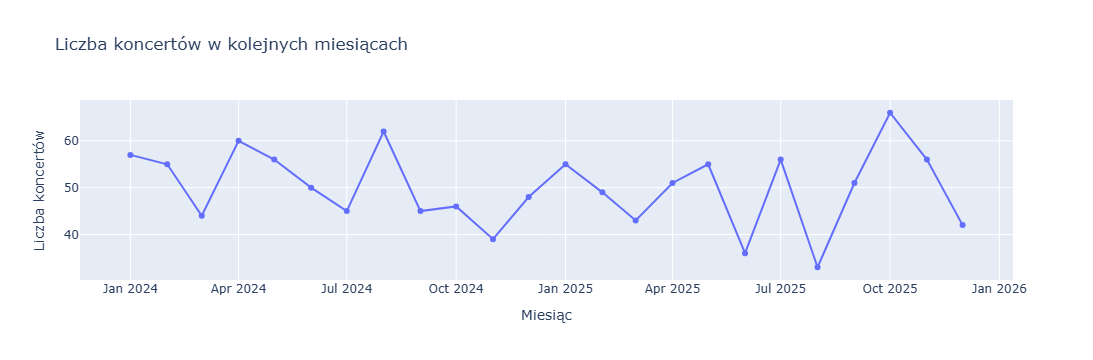

In [5]:
df["miesiac"] = df["data"].dt.to_period("M").astype(str)

koncerty_miesiac = (
    df.groupby("miesiac")
    .size()
    .reset_index(name="liczba_koncertow")
)

fig = px.line(
    koncerty_miesiac,
    x="miesiac",
    y="liczba_koncertow",
    markers=True,
    title="Liczba koncertów w kolejnych miesiącach",
    labels={
        "miesiac": "Miesiąc",
        "liczba_koncertow": "Liczba koncertów"
    }
)

fig.show()

### Komentarz

Wykres przedstawia liczbę koncertów organizowanych w kolejnych miesiącach. Pozwala zauważyć okresy większej i mniejszej aktywności organizatorów wydarzeń muzycznych.

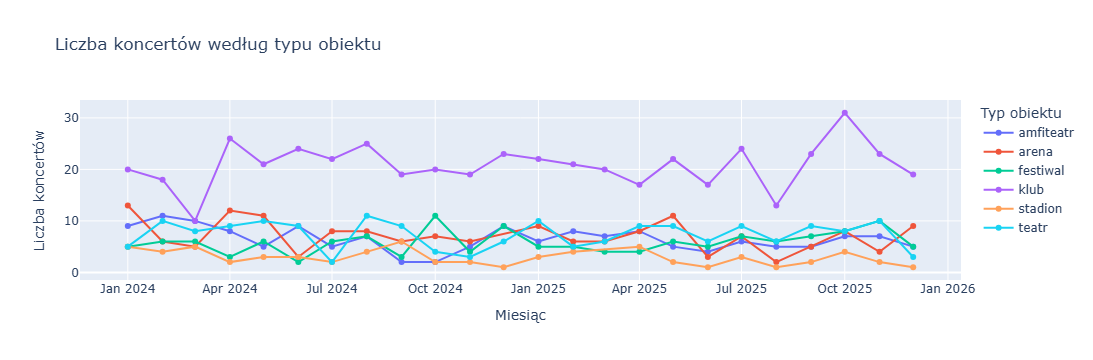

In [6]:
typy = (
    df.groupby(["miesiac", "typ_obiektu"])
    .size()
    .reset_index(name="liczba")
)

fig = px.line(
    typy,
    x="miesiac",
    y="liczba",
    color="typ_obiektu",
    markers=True,
    title="Liczba koncertów według typu obiektu",
    labels={
        "miesiac": "Miesiąc",
        "liczba": "Liczba koncertów",
        "typ_obiektu": "Typ obiektu"
    }
)

fig.show()

### Komentarz

Najwięcej wydarzeń odbywa się w klubach, natomiast koncerty stadionowe oraz festiwale organizowane są znacznie rzadziej.

# Część 4 — Rozkład cen biletów i analiza przychodów

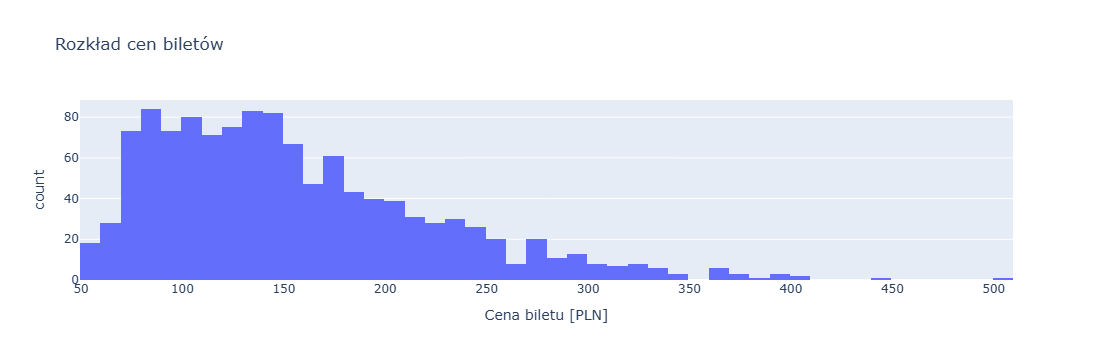

In [7]:
fig = px.histogram(
    df,
    x="cena_biletu_pln",
    nbins=50,
    title="Rozkład cen biletów",
    labels={
        "cena_biletu_pln": "Cena biletu [PLN]"
    }
)

fig.show()

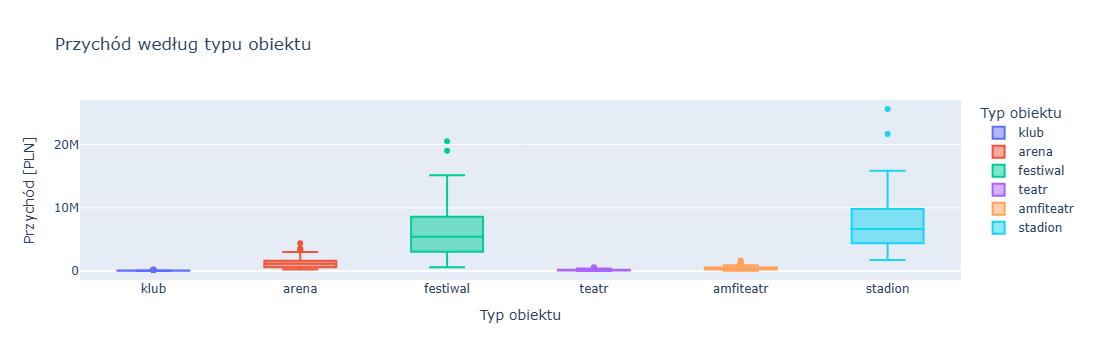

In [8]:
fig = px.box(
    df,
    x="typ_obiektu",
    y="przychod_pln",
    color="typ_obiektu",
    title="Przychód według typu obiektu",
    labels={
        "typ_obiektu": "Typ obiektu",
        "przychod_pln": "Przychód [PLN]"
    }
)

fig.show()

### Komentarz

Największe przychody osiągają koncerty organizowane na stadionach oraz festiwalach. Mimo mniejszej liczby wydarzeń, wysoka pojemność obiektów przekłada się na znacznie większe wpływy ze sprzedaży biletów.

### Komentarz

Największe przychody osiągają koncerty organizowane na stadionach oraz festiwalach. Mimo mniejszej liczby wydarzeń, wysoka pojemność obiektów przekłada się na znacznie większe wpływy ze sprzedaży biletów.

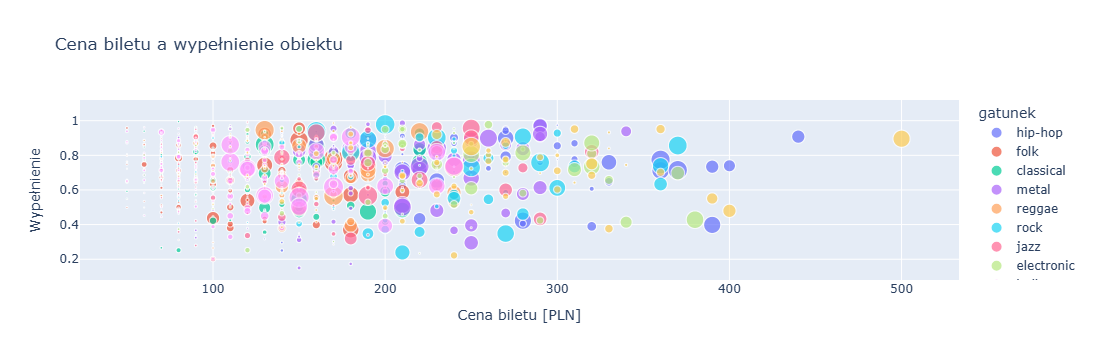

In [9]:
df["wypelnienie"] = (
    df["bilety_sprzedane"] /
    df["pojemnosc"]
)

fig = px.scatter(
    df,
    x="cena_biletu_pln",
    y="wypelnienie",
    color="gatunek",
    size="pojemnosc",
    hover_data=["miasto", "typ_obiektu"],
    title="Cena biletu a wypełnienie obiektu",
    labels={
        "cena_biletu_pln": "Cena biletu [PLN]",
        "wypelnienie": "Wypełnienie"
    }
)

fig.show()

### Komentarz

Nie widać silnej zależności pomiędzy ceną biletu a poziomem wypełnienia obiektu. Zarówno tańsze, jak i droższe koncerty osiągają wysoką frekwencję, co sugeruje, że na zainteresowanie wydarzeniem wpływa również gatunek muzyczny, wykonawca oraz lokalizacja.

# Część 6 — Mapa koncertów w Polsce

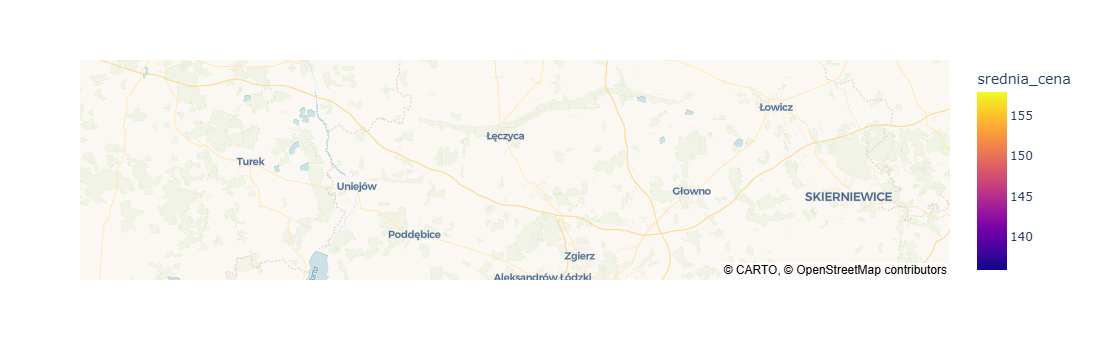

In [13]:
mapa = (
    df.groupby("miasto")
    .agg(
        srednia_cena=("cena_biletu_pln", "mean"),
        liczba_koncertow=("event_id", "count"),
        przychod=("przychod_pln", "sum"),
        latitude=("latitude", "first"),
        longitude=("longitude", "first")
    )
    .reset_index()
)

fig = px.scatter_mapbox(
    mapa,
    lat="latitude",
    lon="longitude",
    size="liczba_koncertow",
    color="srednia_cena",
    hover_name="miasto",
    hover_data=[
        "liczba_koncertow",
        "srednia_cena",
        "przychod"
    ],
    mapbox_style="open-street-map",
    center={
        "lat": 52.0,
        "lon": 19.2
    },
    zoom=5,
    height=700,
    title="Mapa koncertów w Polsce"
)

fig.show()

### Komentarz

Największa liczba koncertów organizowana jest w największych polskich miastach. Wielkość punktu przedstawia liczbę wydarzeń, natomiast kolor oznacza średnią cenę biletu.

# Część 7 — Podsumowanie danych (subploty)

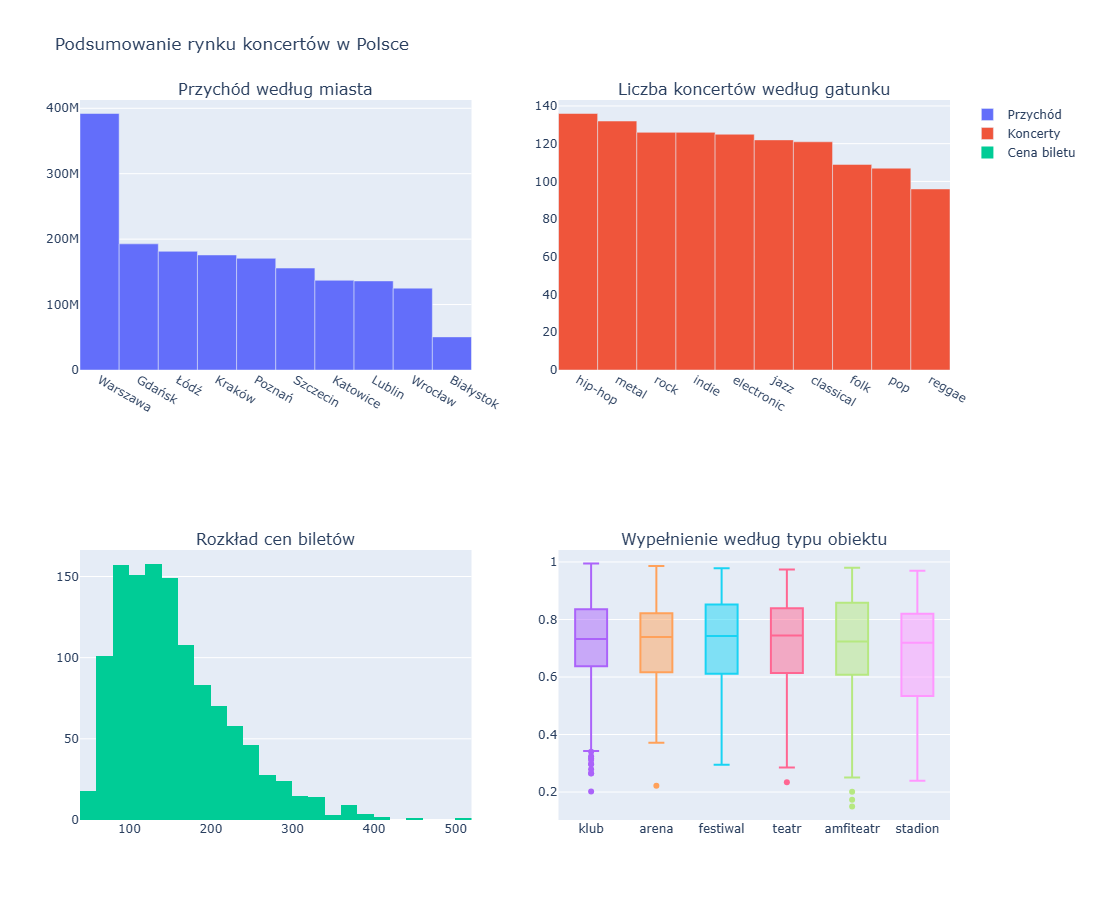

In [11]:
miasta_przychod = (
    df.groupby("miasto")["przychod_pln"]
    .sum()
    .sort_values(ascending=False)
)

gatunki = (
    df.groupby("gatunek")
    .size()
    .sort_values(ascending=False)
)

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "Przychód według miasta",
        "Liczba koncertów według gatunku",
        "Rozkład cen biletów",
        "Wypełnienie według typu obiektu"
    )
)

fig.add_trace(
    go.Bar(
        x=miasta_przychod.index,
        y=miasta_przychod.values,
        name="Przychód"
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Bar(
        x=gatunki.index,
        y=gatunki.values,
        name="Koncerty"
    ),
    row=1,
    col=2
)

fig.add_trace(
    go.Histogram(
        x=df["cena_biletu_pln"],
        nbinsx=40,
        name="Cena biletu"
    ),
    row=2,
    col=1
)

for typ in df["typ_obiektu"].unique():

    fig.add_trace(
        go.Box(
            y=df[df["typ_obiektu"] == typ]["wypelnienie"],
            name=typ,
            showlegend=False
        ),
        row=2,
        col=2
    )

fig.update_layout(
    title="Podsumowanie rynku koncertów w Polsce",
    height=900
)

fig.show()

# Część 8 — Wnioski

## Najważniejsze wnioski

1. **Warszawa** generuje najwyższy łączny przychód z organizacji koncertów oraz jest miastem z największą liczbą wydarzeń.

2. Najwięcej koncertów organizowanych jest w **klubach**, natomiast najwyższe przychody osiągają **stadiony** oraz **festiwale** dzięki dużej pojemności obiektów.

3. Rozkład cen biletów pokazuje, że większość wydarzeń mieści się w średnim przedziale cenowym, a bardzo drogie koncerty stanowią niewielki odsetek wszystkich wydarzeń.

4. Nie zaobserwowano wyraźnej zależności pomiędzy ceną biletu a stopniem wypełnienia obiektu. O frekwencji decydują również inne czynniki, takie jak popularność wykonawcy czy lokalizacja.

5. Analiza miesięcznej liczby koncertów wskazuje na występowanie zmian aktywności organizatorów w czasie, co może świadczyć o sezonowości rynku koncertowego.